# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

What can be said about the outliers in the top left? 
    • They were low on PCA 1's spread, but high on PCA 2's
    • This combination is more unique within this data set (not seen in many other points)


Is the first PCA score high or low?
    • PCA1 has a highest value of .9159
    • From my googling, there is no set threshold to determine if a PCA is "high" or "low", but it seems like this accounts for a large majority of variation
    • Values seem more clustered around 0, but a decent proportion fall either low or high


Is the second PCA score high or low?
    • 2 variables seem to account for a lot of the variation in PCA2 with values of .603 and .689
    • These are lower values than PCA, but combined with PCA much of the variation is accounted for 
    • Values are more clustered around 0 than in PCA1, but there is still a wide spread of values. On visual inspection, it seems that more values fall lower than 0 compared to the higher values


What does that mean about their values in series_1, series_2, and series_3?
    • A wide spread with no obvious clusters implies that on a multivariate level there is a lot of variation amongst the samples


Thoughts on series_3?
    • Series 3 is a significant contributor to the variation - looking at PCA1 the variation is primarily explained by series3 data & much of PCA2 is also explained by this data


Why is it harder to say something about series_1 and series_2?
    • Series 3 dominates PCA1 compared to series 1 and 2
    • Series 1 and 2 have very similar values in PCA2, but PCA explains a significantly lower proportion of the variance than PCA1 does


How are series_1 and series_2 related? Look at how they were made
    • Both series 2 and 3 start with the series 1 data and then are multiplied by random numbers
    • I think that might make them linearly dependent


Advantages
    • Lower dimensional plot than trying to plot all 3 series at once
    • The spread can be used for a quick visual inspection of the relationships between the PCAs
    • Clustering of values can be useful


Disadvantages
    • Very much relies on an audience who understands statistics
    • Can't see all 3 series (maybe a bubble plot would be appropriate?)
    • Can't interpret in a concrete way - need other analyses to do so


In [1]:
# ! pip install matplotlib
# ! pip install pandas
# ! pip install numpy
# ! pip install scikit-learn

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

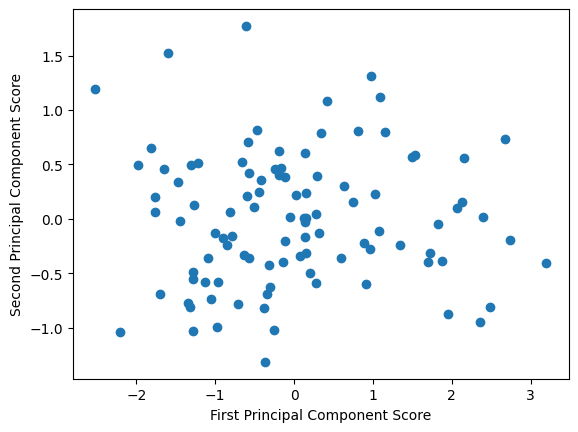

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Column scales

Column	Scale


Diabetes_binary	0=No diabetes; 1=Prediabetes or Diabetes


HighBP	0=No high BP; 1=High BP


HighChol	0=No high cholesterol; 1=High cholesterol


CholCheck	0=No cholesterol check in 5 years; 1=Cholesterol in 5 years


BMI	BMI score


Smoker	0=Has not smoked 100 cigarettes;Yes=Has smoked 100 cigarettes


Stroke	0=No stroke BP; 1=Has had a stroke


HeartDiseaseorAttack	0=No heart disease or attack; 1=Has heart disease or attack


PhysActivity	0=No physical activity in 30 days; 1=Has had physical activity in 30 days


Fruits	0=No daily fruits; 1=1+ daily fruits


Veggies	0=No daily vegetables; 1=1+ daily vegetables


HvyAlcoholConsump	0=No heavy alcohol consumption;1=Heavy alcohol consumption


AnyHealthcare	0=No health coverage;1=Health coverage


NoDocbcCost	0=Did not avoid doctor due to cost;1=Avoided doctor due to cost


GenHlth	1=Excellent;1=Very good;3=Good;4=Fair;5=Poor


MentHlth	0=0 days poor mental health;1=1 days poor mental health;2=2 days poor mental health;3=3 days poor mental health;4=4 days poor mental health;5=5 days poor mental health;6=6 days poor mental health;7=7 days poor mental health;8=8 days poor mental health;9=9 days poor mental health;10=10 days poor mental health;11=11 days poor mental health;12=12 days poor mental health;13=13 days poor mental health;14=14 days poor mental health;15=15 days poor mental health;16=16 days poor mental health;17=17 days poor mental health;18=18 days poor mental health;19=19 days poor mental health;20=20 days poor mental health;21=21 days poor mental health;22=22 days poor mental health;23=23 days poor mental health;24=24 days poor mental health;25=25 days poor mental health;26=26 days poor mental health;27=27 days poor mental health;28=28 days poor mental health;29=29 days poor mental health;30=30 days poor mental health


PhysHlth	0=0 days poor physical health;1=1 days poor physical health;2=2 days poor physical health;3=3 days poor physical health;4=4 days poor physical health;5=5 days poor physical health;6=6 days poor physical health;7=7 days poor physical health;8=8 days poor physical health;9=9 days poor physical health;10=10 days poor physical health;11=11 days poor physical health;12=12 days poor physical health;13=13 days poor physical health;14=14 days poor physical health;15=15 days poor physical health;16=16 days poor physical health;17=17 days poor physical health;18=18 days poor physical health;19=19 days poor physical health;20=20 days poor physical health;21=21 days poor physical health;22=22 days poor physical health;23=23 days poor physical health;24=24 days poor physical health;25=25 days poor physical health;26=26 days poor physical health;27=27 days poor physical health;28=28 days poor physical health;29=29 days poor physical health;30=30 days poor physical health


DiffWalk	0=No difficulty walking;1=Difficulty walking


Sex	0=Female;1=Male


Age	1=18 to 24;2=25 to 29;3=30 to 34;4=35 to 39;5=40 to 44;6=45 to 49;7=50 to 54;8=55 to 59;9=60-64;10=65 to 69;11=70 to 74;12=75 to 79;8=80 or older


Education	1=Never attended or only kindergarten;2=Elementary school;3=Some high school;4=High school or GED;5=Some college;6=Graduated college


Income	1=Less than 10k;2=10k to less than 15k;3=15k to less than 20k;4=20k to less than 25k;5=25k to less than 35k;6=35k to less than 50k;7=50k to less than 75k;8=75k or more


## Conclusions

Heatmaps


    • High Cholesterol Prevalence by Education and Income: darker colors are mainly in the lower income and education categories - seems to be a correlation there
    • Diabetes Prevalence by Education and Income: Similar, but more compelling relationships here. Lower education and lower income are more strongly associated with diabetes diagnosis. The lower right area has very little color - seems that people with higher education and higher income have much lower rates of diabetes.
    • Diabetes Prevalence by Health Coverage and Physical Activity: Lower physical activity has a high association with diabetes diagnosis. Healthcare coverage doesn't have as noticeable a relationship. 


Bubble plots


    • PCA1 vs. PCA2 by BMI: Very dense plot due to sample size. No distinct clouds. Can't see that the bubble size is varied.
    • PCA2 vs. Income by Education: It looks a bit startling at first, but the income data is categorical so it makes sense that we're seeing it like this. Can see some variation in bubble size so we know it's working. Seems like bubble plots may not be ideal for this dataset.


PCA - can you use fewer dimensions?


    • No clear groupings from the PCA. First 2 PCAs only explain about 25% of the variation. Plots shows an overlapping cloud. I don't think it would make sense to lower the dimension.
    • Because of how the data was formatted (largely binary and categorical values I scaled the data to run the PCAs.


Linear Regression


    • Most of the features are not continuous, logistic regressions would probably work better for those
    • Can do linear regression on BMI and maybe PCA2 - I only did BMI
    • R2: explains abouut 10% of variation, not very high
    • MSE/RMSE: the model doesn't do a great job at accurately predicting. RMSE shows that the predictions are off by 6.4 BMI points on average
    • People with diabetes on average have a 3.08 higher BMI
    • People with high bp on average have a 2.47 higher BMI
    • People who are physically active on average have a 1.52 lower BMI
    • Heavy alcohol consumption is also correlated with a 1.52 decreased BMI which is surprising to me


Is the data useable?


    • Clear relationships between variables
    • Plenty of columns and rows
    • Yes, data seems useable
    • Comparing to the codebook, looks like this dataset excluded any missed or unknown values already which cut down on the pre-processing time


Outliers?


    • Does seem like BMI has outliers - max value is 98, which is an unlikely BMI value
    • Also some very low BMIs (min is 12), which would be severely underweight. It is possible that someone has this BMI, but they would be very underweight.
    • PCAs showed some outliers as well, but honestly not very many.


General thoughts


    • Interesting socioeconomic trends we're observing. Specifically related to physical activity, education, and income


In [3]:
# starting with diabetes data
diabetes = pd.read_csv("diabetes_data.csv", sep=",")

diabetes.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [5]:
diabetes.isnull().sum().sort_values()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [6]:
diabetes.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
# clean the dataset in the same way as Milestone 3 by dropping duplicated values
diabetes.duplicated().sum()

np.int64(24206)

In [8]:
diabetes_clean = diabetes.drop_duplicates()
diabetes_clean.duplicated().sum()

np.int64(0)

In [9]:
# going to isolate columns of interest as done for Milestone 3
diabetes_coi = diabetes_clean[['Diabetes_binary','HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker','Stroke', 'HeartDiseaseorAttack', 'PhysActivity','HvyAlcoholConsump', 'AnyHealthcare', 'Sex', 'Age', 'Education','Income']]

In [10]:
diabetes_coi.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,Sex,Age,Education,Income
count,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.00000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000
mean,0.152945,0.454343,0.441640,0.959481,28.687507,0.46580,0.044816,0.103336,0.733042,0.060791,0.946011,0.439087,8.085068,4.979741,5.888615
std,0.359936,0.497912,0.496584,0.197173,6.789204,0.49883,0.206899,0.304398,0.442371,0.238947,0.225996,0.496277,3.094451,0.992989,2.092888
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.000000,4.000000,4.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.00000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [11]:
# not scaled

# # start with PCA
# # reference: 8.5 Lesson: Principal Components for Visualization (Mod 1 Math)
# # check: PCA needs numeric columns, all COI are numeric
# from sklearn.decomposition import PCA
# pca1 = PCA()
# pca1.fit(diabetes_coi)
# components1 = pd.DataFrame(pca1.components_, columns=diabetes_coi.columns)
# print(pca1.explained_variance_ratio_)
# components1

# # findings
# # explained variance ratio
# # [7.37168730e-01 1.55715174e-01 7.09540349e-02 1.24480992e-02
# #  4.66846638e-03 3.93876851e-03 3.47703417e-03 2.91569811e-03
# #  2.73498679e-03 1.78085561e-03 1.31270904e-03 8.84729945e-04
# #  7.91197434e-04 6.28256508e-04 5.81259283e-04]

# # PCA
# # PCA1=BMI 0.999069
# # PCA2=Age 0.982870
# # PCA3=Income 0.958388
# # PCA4=Education 0.965665
# # PCA5=HighBP 0.446962;HighChol 0.512200;Smoker 0.461445;Sex 0.505207


In [12]:
# need to scale the data to run the PCA (otherwise the binary columns will be outshined by the non-binary columns)
# reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
diabetes_scaledcoi = scaler.fit_transform(diabetes_coi)

diabetes_dfscaledcoi = pd.DataFrame(diabetes_scaledcoi, columns=diabetes_coi.columns)
diabetes_dfscaledcoi.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,Sex,Age,Education,Income
0,-0.424925,1.095892,1.124404,0.205499,1.666251,1.070908,-0.216606,-0.339478,-1.657077,-0.254413,0.238893,-0.884764,0.295669,-0.986660,-1.380208
1,-0.424925,-0.912499,-0.889360,-4.866203,-0.543144,1.070908,-0.216606,-0.339478,0.603472,-0.254413,-4.185976,-0.884764,-0.350650,1.027465,-2.335828
2,-0.424925,1.095892,1.124404,0.205499,-0.101265,-0.933787,-0.216606,-0.339478,-1.657077,-0.254413,0.238893,-0.884764,0.295669,-0.986660,1.008840
3,-0.424925,1.095892,-0.889360,0.205499,-0.248558,-0.933787,-0.216606,-0.339478,0.603472,-0.254413,0.238893,-0.884764,0.941989,-1.993722,0.053221
4,-0.424925,1.095892,1.124404,0.205499,-0.690437,-0.933787,-0.216606,-0.339478,0.603472,-0.254413,0.238893,-0.884764,0.941989,0.020402,-0.902399


In [13]:
# reference: 8.5 Lesson: Principal Components for Visualization (Mod 1 Math)
# now try the PCA again
from sklearn.decomposition import PCA
pca1 = PCA()
pca1.fit(diabetes_dfscaledcoi)
components1 = pd.DataFrame(pca1.components_, columns=diabetes_dfscaledcoi.columns)
print(pca1.explained_variance_ratio_)
components1

# findings

# explained variance ration - reminder that this is how much of the variance the PCAs explain, not columns
# [0.15745372 0.09974817 0.08027375 0.07661993 0.06921557 0.06268189
#  0.06211152 0.06091963 0.05550049 0.05254529 0.05102532 0.04953067
#  0.04795263 0.03799785 0.03642356]

# PCA
# PCA1: (Diabetes_binary,0.343834); (HighBP,0.414597); (HighChol,0.331560); (HeartDiseaseorAttack,0.323779); (Age,0.367565); (Education,0.277420); (Income,0.306119)
# PCA2: (HighBP,0.183193); (HighChol,0.246650); (CholCheck,0.240499); (PhysActivity,0.238659); (AnyHealthcare,0.446423); (Age,0.247411); (Education,0.482282); (Income,0.493204)
# PCA3: (BMI,0.468818); (Smoker,0.534697); (HvyAlcoholConsump,0.416763); (Sex,0.288481)

# variance ratios imply that there are no dominating PCAS to explain the variance
# first 2 PCAs only account for about 25% of the variation
# I think this means that it would be harder to bring this data down into a lower dimension

# project insight - socioeconomuc factors in chronic illness (diabetes)
# PCA1: People who are older and have more health problems tend to cluster together & income and education also factor into that cluster
# PCA2: People with higher income and education tend to have better access to healthcare, go to the doctor more, and are more physicaly active
# PCA2 is probs the most relevant for my project
# PCA3 shows that certain lifestle habits tend to happen together - smoking, drinking, BMI and they show differences in gender

[0.15745372 0.09974817 0.08027375 0.07661993 0.06921557 0.06268189
 0.06211152 0.06091963 0.05550049 0.05254529 0.05102532 0.04953067
 0.04795263 0.03799785 0.03642356]


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,Sex,Age,Education,Income
0,0.343834,0.414597,0.331560,0.129055,0.188606,0.169347,0.228164,0.323779,-0.222483,-0.074822,0.031916,0.016342,0.367565,-0.277420,-0.306119
1,0.069683,0.183193,0.246650,0.240499,-0.053002,-0.081152,0.024177,0.120474,0.238659,0.044289,0.446423,0.152130,0.247411,0.482282,0.493204
2,-0.230529,-0.072320,-0.000383,-0.201013,-0.468818,0.534697,0.191740,0.238582,0.112927,0.416763,-0.085134,0.288481,0.144116,-0.063166,0.013044
3,0.224913,0.092130,0.024583,-0.196291,0.489936,0.145850,-0.128570,0.042473,-0.040664,0.082692,-0.255774,0.629303,-0.314621,0.084798,0.214562
4,-0.021853,0.104530,0.073365,0.272923,0.167958,0.295668,-0.455852,-0.357056,-0.227047,0.569017,0.186362,-0.188997,0.017831,-0.107158,0.014972
5,-0.101214,-0.143439,-0.176655,0.575826,-0.104426,0.259088,-0.223145,0.002756,0.108229,-0.443457,0.169868,0.393089,-0.045838,-0.282035,-0.071962
6,-0.050244,-0.189989,-0.355199,0.242171,0.211697,0.037601,0.574845,0.149698,-0.424839,0.178745,0.304336,-0.017755,-0.247620,0.069374,0.077317
7,0.085663,0.061802,0.050269,0.514894,0.065902,-0.146409,0.245961,0.039929,0.536601,0.339240,-0.403721,-0.088332,-0.213019,-0.024997,-0.116237
8,0.325510,-0.028967,-0.264897,-0.308515,0.227250,0.276394,0.084682,-0.099378,0.554175,-0.004311,0.460235,-0.150598,-0.052456,-0.132065,-0.144744
9,-0.016407,-0.156374,0.313810,0.072894,0.120905,0.607350,0.175884,-0.166569,-0.016502,-0.349437,-0.241486,-0.350659,-0.118593,0.301642,0.143549


Text(0, 0.5, 'PCA 2 score')

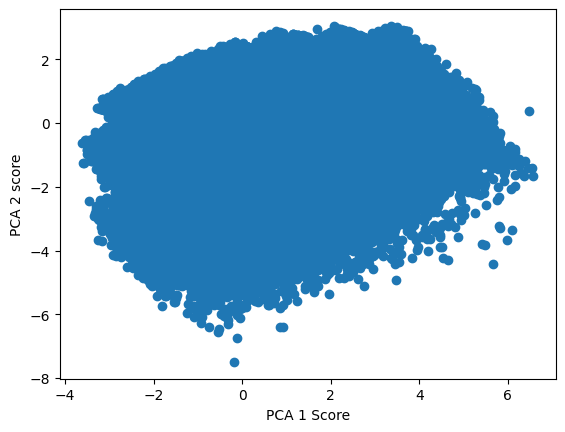

In [14]:
# lets try plotting the PCAs following the code setup from the weekly graph
pca1_score1 = diabetes_dfscaledcoi.dot(pca1.components_[0])
pca1_score2 = diabetes_dfscaledcoi.dot(pca1.components_[1])
plt.scatter(pca1_score1, pca1_score2)
plt.xlabel("PCA 1 Score")
plt.ylabel("PCA 2 score")

# findings
# wow that is one giant cloud lol
# reaffirms what we saw from the PCA scores - no one PCA seems to fully be driving the variation
# going back to week 8's example, since PCA1 does not explain a significant portion of the variance it wouldn't make much sense to project along PCA1

Text(0.5, 1.0, 'PCA1 vs. PCA2 by BMI')

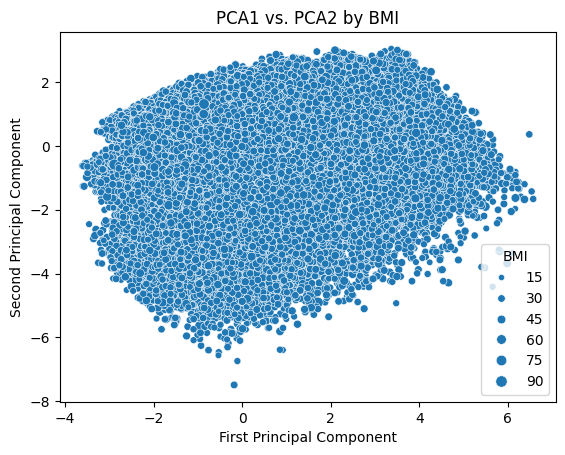

In [15]:
# lets do some bubble plots now!
# ! pip install seaborn
import seaborn as sns
bubble_pca1 = sns.scatterplot(data=diabetes_dfscaledcoi, x=pca1_score1, y=pca1_score2, size = diabetes_coi["BMI"])
bubble_pca1.set_xlabel ("First Principal Component")
bubble_pca1.set_ylabel("Second Principal Component")
bubble_pca1.set_title("PCA1 vs. PCA2 by BMI")

Text(0.5, 1.0, 'PCA2 vs. Income by Education')

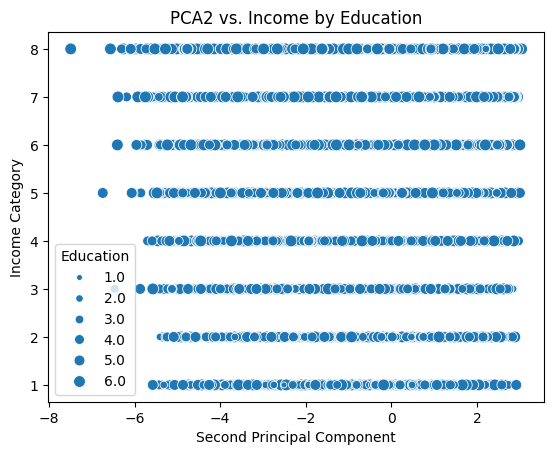

In [16]:
# bubble plot of PCA2 against Income and Education
bubble_pca2 = sns.scatterplot(data=diabetes_dfscaledcoi, x=pca1_score2, y=diabetes_coi["Income"], size = diabetes_coi["Education"])
bubble_pca2.set_xlabel ("Second Principal Component")
bubble_pca2.set_ylabel("Income Category")
bubble_pca2.set_title("PCA2 vs. Income by Education")

# it looks a bit starting at first, but the income data is categorical so it makes sense that we're seeing it like this
# can see some variation in bubble size so we know it's working
# seems like bubble plots may not be ideal for this dataset

Text(50.722222222222214, 0.5, 'Education Category')

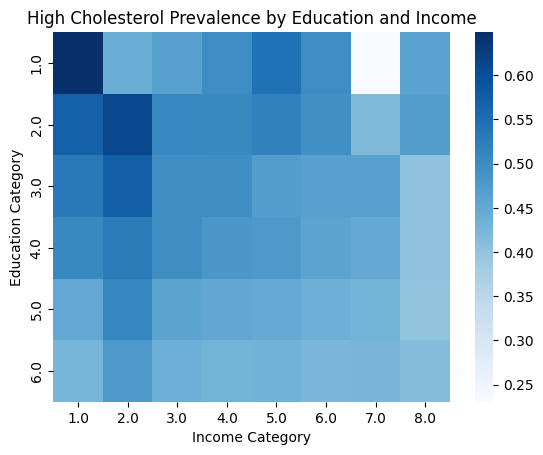

In [17]:
# lets try some heatmaps now - reminder from the live session to not use too many variables with these!
# going to focus first on the columns from PCA2
# # PCA2: (HighBP,0.183193); (HighChol,0.246650); (CholCheck,0.240499); (PhysActivity,0.238659); (AnyHealthcare,0.446423); (Age,0.247411); (Education,0.482282); (Income,0.493204)
# follow the example from week 8's lesson
pivot1 = diabetes_coi.pivot_table(index="Education", columns="Income", values="HighChol", aggfunc="mean")
sns.heatmap(pivot1, cmap="Blues")
plt.title("High Cholesterol Prevalence by Education and Income")
plt.xlabel("Income Category")
plt.ylabel("Education Category")

# darker colors are mainly in the lower income and education categories - seems to be a correlation there

Text(50.722222222222214, 0.5, 'Education Category')

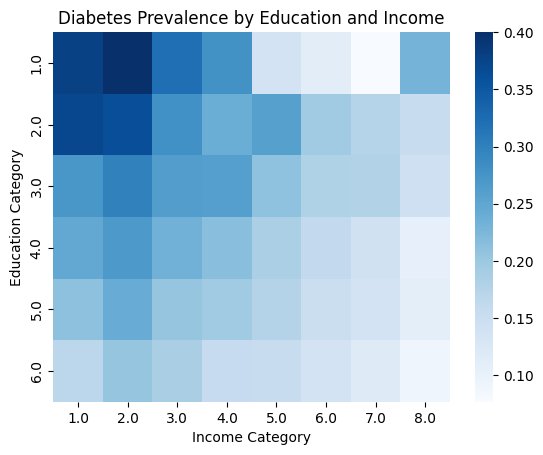

In [18]:
# let's try the same thing but with Diabetes
pivot2 = diabetes_coi.pivot_table(index="Education", columns="Income", values="Diabetes_binary", aggfunc="mean")
sns.heatmap(pivot2, cmap="Blues")
plt.title("Diabetes Prevalence by Education and Income")
plt.xlabel("Income Category")
plt.ylabel("Education Category")

# Similar, but more compelling relationships here
# lower education and lower income are more strongly associated with diabetes diagnosis
# the lower right area has very little color - seems that people with higher education and higher income have much lower rates of diabetes

Text(50.722222222222214, 0.5, 'Physical Activity')

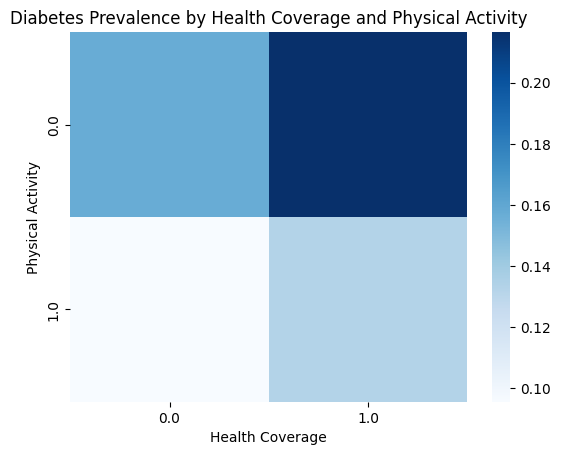

In [19]:
# now let's try that with physical activity and healthcare
pivot2 = diabetes_coi.pivot_table(index="PhysActivity", columns="AnyHealthcare", values="Diabetes_binary", aggfunc="mean")
sns.heatmap(pivot2, cmap="Blues")
plt.title("Diabetes Prevalence by Health Coverage and Physical Activity")
plt.xlabel("Health Coverage")
plt.ylabel("Physical Activity")

# lower physical activity has a high association with diabetes diagnosis
# healthcare coverage doesn't have as noticeable a relationship

In [ ]:
# going to do some linear regressions now
# reminder that they work best with continuous data so it won't work well with a lot of the features
# going to try to predict BMI and PCA2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
bmi_linear = LinearRegression()

# set the variables
bmi_target = diabetes_coi["BMI"]
# print(bmi_target.shape)
bmi_inputs = diabetes_coi.drop(["BMI"], axis=1)
# bmi_variables.columns

# fit the model and predict bmi
bmi_fit = bmi_linear.fit(bmi_inputs, bmi_target)
bmi_predict = bmi_linear.predict(bmi_inputs)
# print("BMI Predictions: ", bmi_predict)

# lets looks at how well the model did
print("R2: ", r2_score(bmi_target, bmi_predict))
print("MSE:", mean_squared_error(bmi_target, bmi_predict))
print("RMSE:", np.sqrt(mean_squared_error(bmi_target, bmi_predict)))
print("Coefficient:", bmi_fit.coef_)
print("Intercept:", bmi_fit.intercept_)

# need to match up the coefficients with the column names to make it easier to interpret
diabetes_coef = pd.DataFrame({
    "Predictor": bmi_inputs.columns, 
    "Coefficient": bmi_fit.coef_})
diabetes_coef

# findings
# R2:  0.10011938229008566
# MSE: 41.47828108813215
# RMSE 6.44036342826491
# Coefficient: [ 3.07808438  2.47029612  0.56374256  0.72345847 -0.32629709 -0.64140967
#  -0.10800295 -1.52437917 -1.26326021  0.15394035  0.27762018 -0.35435387
#  -0.21676933 -0.04109768]
# Intercept: 31.456282573412143

# Predictor	Coefficient
# 0	Diabetes_binary	3.078084
# 1	HighBP	2.470296
# 2	HighChol	0.563743
# 3	CholCheck	0.723458
# 4	Smoker	-0.326297
# 5	Stroke	-0.641410
# 6	HeartDiseaseorAttack	-0.108003
# 7	PhysActivity	-1.524379
# 8	HvyAlcoholConsump	-1.263260
# 9	AnyHealthcare	0.153940
# 10	Sex	0.277620
# 11	Age	-0.354354
# 12	Education	-0.216769
# 13	Income	-0.041098

# interpretations
# R2: explains abouut 10% of variation, not very high
# MSE/RMSE: the model doesn't do a great job at accurately predicting. RMSE shows that the predictions are off by 6.4 BMI points on average
# Coefficients:
# People with:
# diabetes on average have a 3.08 higher BMI
# high bp on average have a 2.47 higher BMI
# physical activity on average have a 1.52 lower BMI
# heavy alcohol seems on average to have a 1.26 lower BMI which is surprising to me
# most of the other associations are smaller
# remember this only accounts for a small amount of variation though so don't make any strong claims


R2:  0.10011938229008566
MSE: 41.47828108813215
RMSE: 6.44036342826491
Coefficient: [ 3.07808438  2.47029612  0.56374256  0.72345847 -0.32629709 -0.64140967
 -0.10800295 -1.52437917 -1.26326021  0.15394035  0.27762018 -0.35435387
 -0.21676933 -0.04109768]
Intercept: 31.456282573412143


,Predictor,Coefficient
0,Diabetes_binary,3.078084
1,HighBP,2.470296
2,HighChol,0.563743
3,CholCheck,0.723458
4,Smoker,-0.326297
5,Stroke,-0.641410
6,HeartDiseaseorAttack,-0.108003
7,PhysActivity,-1.524379
8,HvyAlcoholConsump,-1.263260
9,AnyHealthcare,0.153940


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

Text(0.5, 1.0, 'Distribution of Customers')

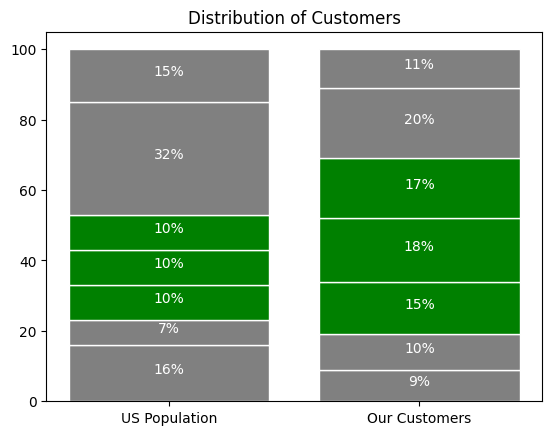

In [21]:
# figure 5.13

# start by making the 2 bar groups, segment names, highlighted groups by index position, and bar position/start
us_population = [16, 7, 10, 10, 10, 32, 15]
customers = [9, 10, 15, 18, 17, 20, 11]
segments = ["Segment 1","Segment 2","Segment 3", "Segment 4", "Segment 5", "Segment 6", "Segment 7"] 
hilighted_segments = [2,3,4]
bar1 = 0
bar2 = 1
bar1_start = 0
bar2_start = 0

# now set the sections to highlight
for c in range(len(us_population)):
    if c in hilighted_segments:
        color = "green"
        text_color = "white"
    else:
        color = "grey"
        text_color = "white"

    # now make the bars
    plt.bar(bar1, us_population[c], bottom=bar1_start, color=color, edgecolor="white")
    plt.text(bar1, bar1_start + us_population[c] / 2, f"{us_population[c]}%", ha="center", color=text_color)
    plt.bar(bar2, customers[c], bottom=bar2_start, color=color, edgecolor="white")
    plt.text(bar2, bar2_start + customers[c] / 2, f"{customers[c]}%", ha="center", color=text_color)
    bar1_start += us_population[c]
    bar2_start += customers[c]

# labels
plt.xticks([bar1, bar2], ["US Population", "Our Customers"])
plt.title("Distribution of Customers")